In [1]:
# =====================================================================
# PLANTILLA GENÉRICA: Clasificación Multiclase con Imágenes de Drive
# =====================================================================

# ---------------------------------------------------------------------
# PASO 1: Conectar a Google Drive
# ---------------------------------------------------------------------
#from google.colab import drive
#drive.mount('/content/drive')

# ---------------------------------------------------------------------
# PASO 2: Importar Librerías
# ---------------------------------------------------------------------
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torchvision.models as models

In [2]:

# Selección automática de hardware
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Trabajando con el dispositivo: {device}\n")

# ---------------------------------------------------------------------
# PASO 3: Configurar Rutas y Número de Clases (¡MODIFICA AQUÍ!)
# ---------------------------------------------------------------------
# Ajusta el nombre de la carpeta raíz si es necesario
RUTA_TRAIN = '/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/train'
RUTA_TEST = '/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/test'
# ---------------------------------------------------------------------
# PASO 4: Carga de Datos y Auto-detección de Clases
# ---------------------------------------------------------------------
transformaciones = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = ImageFolder(root=RUTA_TRAIN, transform=transformaciones)
test_dataset = ImageFolder(root=RUTA_TEST, transform=transformaciones)

# Guardamos dinámicamente cuántas clases detectó ImageFolder en Drive
NUM_CLASES = len(train_dataset.classes) 

print(f"¡Configuración Multiclase Detectada!")
print(f"Número de clases encontradas: {NUM_CLASES}")
print(f"Nombres de las clases: {train_dataset.classes}")
print(f"Mapeo de índices: {train_dataset.class_to_idx}\n")

BATCH_SIZE = 32
train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

Trabajando con el dispositivo: cuda

¡Configuración Multiclase Detectada!
Número de clases encontradas: 6
Nombres de las clases: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Mapeo de índices: {'buildings': 0, 'forest': 1, 'glacier': 2, 'mountain': 3, 'sea': 4, 'street': 5}



In [3]:
# ---------------------------------------------------------------------
# PASO 5: Arquitectura de la CNN Adaptable a N Clases
# ---------------------------------------------------------------------

# 1. Cargamos una estructura ya existente con pesos preentrenados en ImageNet
pesos = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=pesos)
 
# 2. CONGELAMOS las capas base para aprovechar su conocimiento (no se entrenarán)
for param in model.parameters():
    param.requires_grad = False
 
# 3. REEMPLAZAMOS únicamente la última capa (la cabeza de clasificación)
# Conservamos sus características de entrada (512) y le decimos que la salida ahora es 2 (biclase)
num_caracteristicas = model.fc.in_features
model.fc = nn.Linear(num_caracteristicas, NUM_CLASES)
 
# 4. Lo enviamos al hardware
model = model.to(device)

In [4]:
# ---------------------------------------------------------------------
# PASO 6: Función de Pérdida y Optimidad
# ---------------------------------------------------------------------
# Nota para la clase: CrossEntropyLoss maneja internamente Softmax, por lo que
# es perfectamente compatible tanto para biclase como para multiclase en PyTorch.
criterion = nn.CrossEntropyLoss() 
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [5]:
# ---------------------------------------------------------------------
# PASO 7: Bucle de Entrenamiento
# ---------------------------------------------------------------------
NUM_EPOCHS = 15
print("Iniciando el entrenamiento multiclase...")

for epoch in range(NUM_EPOCHS):
    model.train()
    loss_acumulada = 0.0
    
    for imagenes, etiquetas in train_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        
        predicciones = model(imagenes)
        loss = criterion(predicciones, etiquetas)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        loss_acumulada += loss.item()
        
    print(f"Época [{epoch+1}/{NUM_EPOCHS}] - Pérdida Promedio: {loss_acumulada/len(train_loader):.4f}")

print("¡Entrenamiento concluido!\n")

Iniciando el entrenamiento multiclase...
Época [1/15] - Pérdida Promedio: 0.4868
Época [2/15] - Pérdida Promedio: 0.3070
Época [3/15] - Pérdida Promedio: 0.2866
Época [4/15] - Pérdida Promedio: 0.2738
Época [5/15] - Pérdida Promedio: 0.2607
Época [6/15] - Pérdida Promedio: 0.2513
Época [7/15] - Pérdida Promedio: 0.2520
Época [8/15] - Pérdida Promedio: 0.2496
Época [9/15] - Pérdida Promedio: 0.2529
Época [10/15] - Pérdida Promedio: 0.2448
Época [11/15] - Pérdida Promedio: 0.2425
Época [12/15] - Pérdida Promedio: 0.2388
Época [13/15] - Pérdida Promedio: 0.2358
Época [14/15] - Pérdida Promedio: 0.2332
Época [15/15] - Pérdida Promedio: 0.2340
¡Entrenamiento concluido!



In [6]:
# ---------------------------------------------------------------------
# PASO 8: Evaluación Final en el Set de Prueba (Test)
# ---------------------------------------------------------------------
model.eval()
correctos = 0
total_imagenes = 0

with torch.no_grad():
    for imagenes, etiquetas in test_loader:
        imagenes, etiquetas = imagenes.to(device), etiquetas.to(device)
        outputs = model(imagenes)
        _, predicciones_indices = torch.max(outputs.data, 1)
        
        total_imagenes += etiquetas.size(0)
        correctos += (predicciones_indices == etiquetas).sum().item()

accuracy = 100 * correctos / total_imagenes
print(f"Exactitud (Accuracy) final en TEST para las {NUM_CLASES} clases: {accuracy:.2f}%")

Exactitud (Accuracy) final en TEST para las 6 clases: 91.37%


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..2.64].


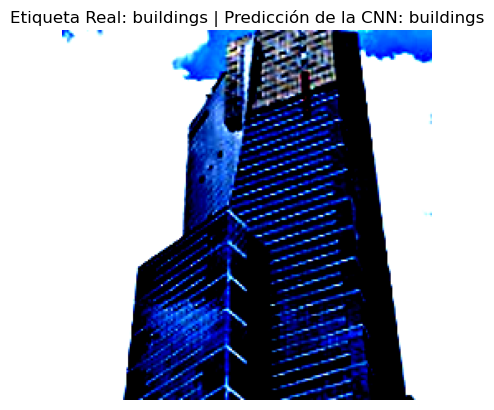

In [7]:
imagenes_muestra, etiquetas_muestra = next(iter(test_loader))
con_prediccion = model(imagenes_muestra.to(device))
_, prediccion = torch.max(con_prediccion, 1)

idx_to_class = {v: k for k, v in train_dataset.class_to_idx.items()}

# Dibujar el primer elemento del lote
plt.imshow(imagenes_muestra[0].squeeze().numpy().transpose(1, 2, 0))
plt.title(f"Etiqueta Real: {idx_to_class[etiquetas_muestra[0].item()]} | Predicción de la CNN: {idx_to_class[prediccion[0].item()]}")
plt.axis('off')
plt.show()

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10004.jpg


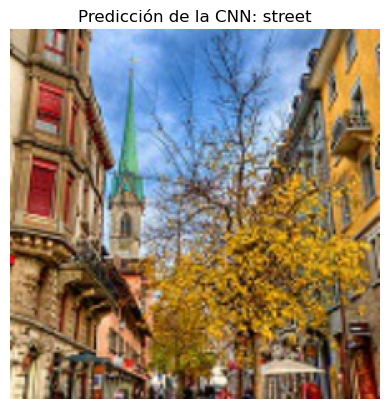

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10005.jpg


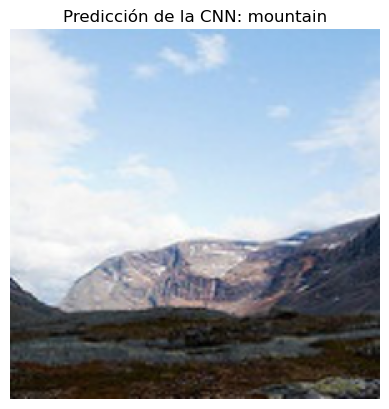

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10012.jpg


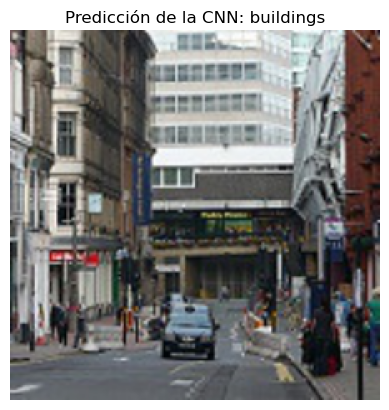

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10013.jpg


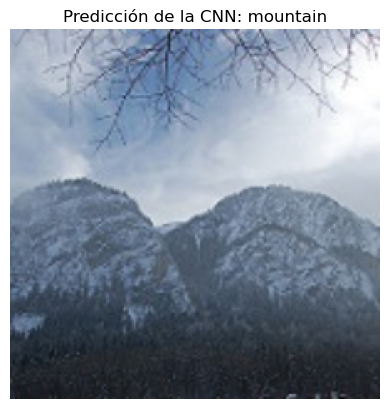

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10017.jpg


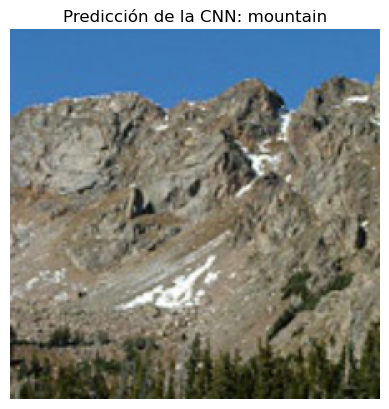

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10021.jpg


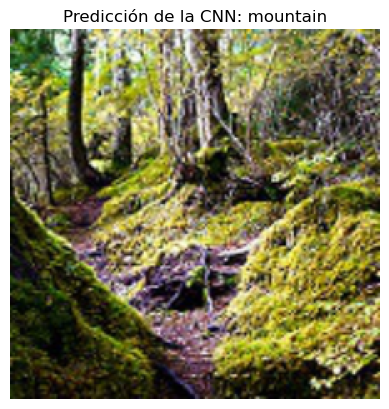

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/1003.jpg


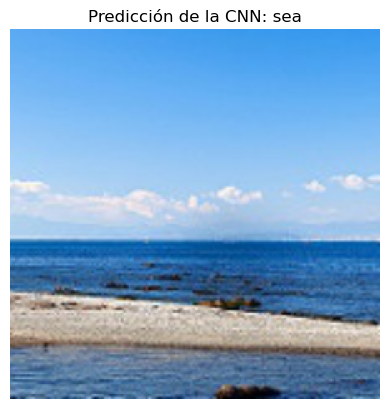

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10034.jpg


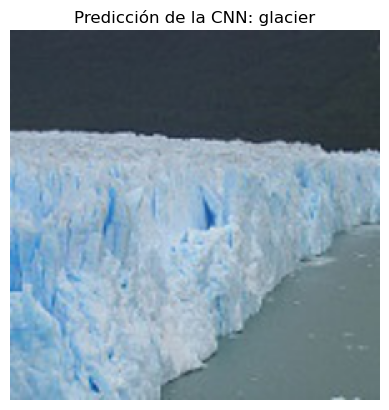

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10038.jpg


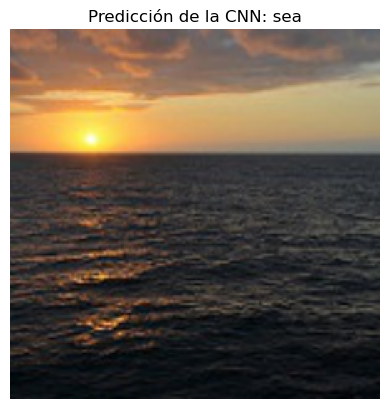

/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/10040.jpg


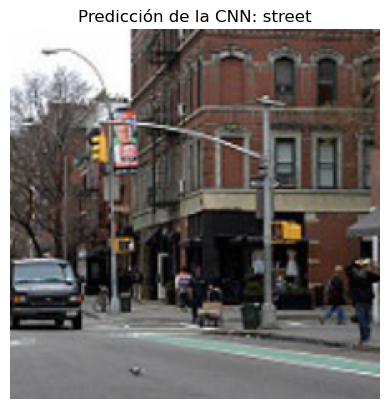

In [8]:
from pathlib import Path
import cv2

RUTA_PRED = '/home/pprezp/Documentos/Desarrollos/DSRN_UAEMEX/Modulo_04/CNN_Multiclase/pred/'

folder = Path(RUTA_PRED)
imagenes = [ str.lower(f.name) for f in folder.glob('*.jpg*') if f.is_file() ]


for i in range( 10 ):
    img = cv2.imread( RUTA_PRED + imagenes[i] )
    print( RUTA_PRED + imagenes[i] )
    image_resized = cv2.resize(img, (224, 224))
    img_rgb = cv2.cvtColor(image_resized, cv2.COLOR_BGR2RGB)

    tensor_kitten = torch.from_numpy(img_rgb).permute(2, 0, 1).float() / 255.0
    tensor_kitten = tensor_kitten.unsqueeze(0)

    con_prediccion = model(tensor_kitten.to(device))
    _, prediccion = torch.max(con_prediccion, 1)

    plt.imshow(tensor_kitten.squeeze().numpy().transpose(1, 2, 0))
    plt.title(f"Predicción de la CNN: {idx_to_class[prediccion[0].item()]}")
    plt.axis('off')
    plt.show()


In [9]:
# 2. Extract and save only the structural state weights
torch.save(model, "image_classifier_model.pth")
print("Weights exported successfully!")

Weights exported successfully!
